# DoWhy
## Sensitivity Analysis for Regression Models  
Source: https://www.pywhy.org/dowhy/v0.9.1/example_notebooks/sensitivity_analysis_testing.html  

Sensitivity analysis helps us examine how sensitive a result is against the possibility of unobserved confounding.  
Two methods are implemented: 
1. Cinelli & Hazlett’s robustness value,   
https://carloscinelli.com/files/Cinelli%20and%20Hazlett%20(2020)%20-%20Making%20Sense%20of%20Sensitivity.pdf   
- This method only supports linear regression estimator. 
- The partial R^2 of treatment with outcome shows how strongly confounders explaining all the residual outcome variation would have to be associated with the treatment to eliminate the estimated effect. 
- The robustness value measures the minimum strength of association unobserved confounding should have with both treatment and outcome in order to change the conclusions. 
- Robustness value close to 1 means the treatment effect can handle strong confounders explaining almost all residual variation of the treatment and the outcome. 
- Robustness value close to 0 means that even very weak confounders can also change the results. 
- Benchmarking examines the sensitivity of causal inferences to plausible strengths of the omitted confounders. 
- This method is based on https://carloscinelli.com/files/Cinelli%20and%20Hazlett%20(2020)%20-%20Making%20Sense%20of%20Sensitivity.pdf 

2. Ding & VanderWeele’s E-Value  
https://dash.harvard.edu/bitstream/handle/1/36874927/EValue_FinalSubmission.pdf   
- This method supports linear and logistic regression. 
- The E-value is the minimum strength of association on the risk ratio scale that an unmeasured confounder would need to have with both the treatment and the outcome, conditional on the measured covariates, to fully explain away a specific treatment-outcome association. - The minimum E-value is 1, which means that no unmeasured confounding is needed to explain away the observed association (i.e. the confidence interval crosses the null). 
- Higher E-values mean that stronger unmeasured confounding is needed to explain away the observed association. There is no maximum E-value. 
- McGowan & Greevy Jr’s benchmarks the E-value against the measured confounders.  
See "Contextualizing E-values for Interpretable Sensitivity to Unmeasured Confounding Analyses", https://arxiv.org/abs/2011.07030

In [1]:
# If needed, uninstall networkx, so I can install a specific version
try:
    import networkx
    !uv pip uninstall networkx
    print("networkx uninstalled.")
except ImportError:
    pass
    print("networkx not installed, skipping uninstall step.")

# Install a specific version of networkx
!uv add networkx==2.8.8

Using Python 3.12.3 environment at: /home/tc_unix/causal-inference-in-python-code/.venv
Uninstalled 1 package in 44ms
 - networkx==2.8.8
networkx uninstalled.
Resolved 148 packages in 3ms
Installed 1 package in 65ms                                 
 + networkx==2.8.8


In [2]:
# If needed, Install "ipywidgets" using uv
try:
    import ipywidgets
    print("ipywidgets is already installed.")
except ImportError:
    print("ipywidgets not found. Installing using uv...")
    !uv add ipywidgets
    import ipywidgets

# If needed, Install "dowhy" using uv
try:
    import dowhy
    print("dowhy is already installed.")
except ImportError:
    print("dowhy not found. Installing using uv...")
    !uv add dowhy
    import dowhy

ipywidgets is already installed.
dowhy is already installed.


## Step 1: Load required packages

In [3]:
# Step 1: Load required packages
import os, sys
sys.path.append(os.path.abspath("../../../"))
import dowhy
from dowhy import CausalModel
import pandas as pd
import numpy as np
import dowhy.datasets

# Config dict to set the logging level
import logging.config
DEFAULT_LOGGING = {
    'version': 1,
    'disable_existing_loggers': False,
    'loggers': {
        '': {
            'level': 'ERROR',
        },
    }
}

logging.config.dictConfig(DEFAULT_LOGGING)
# Disabling warnings output
import warnings
from sklearn.exceptions import DataConversionWarning
#warnings.filterwarnings(action='ignore', category=DataConversionWarning)

## Step 2: Load the dataset  
We create a dataset with linear relationships between common causes and treatment,   
and common causes and outcome.   
Beta is the true causal effect.  

In [4]:
np.random.seed(100)
data = dowhy.datasets.linear_dataset( beta = 10,
                                      num_common_causes = 7,
                                      num_samples = 500,
                                      num_treatments = 1,
                                     stddev_treatment_noise =10,
                                     stddev_outcome_noise = 5
                                    )

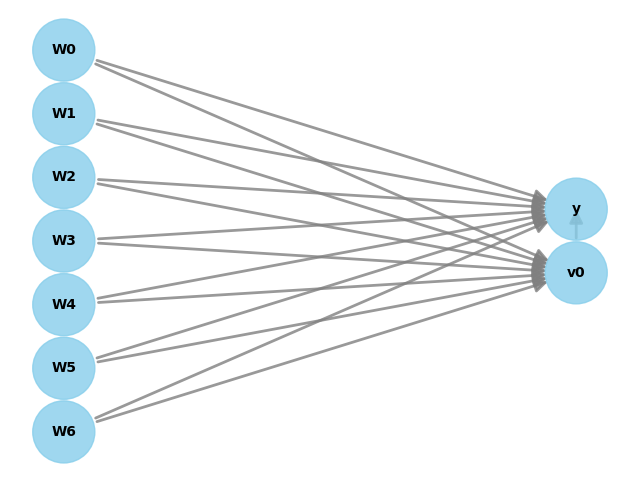

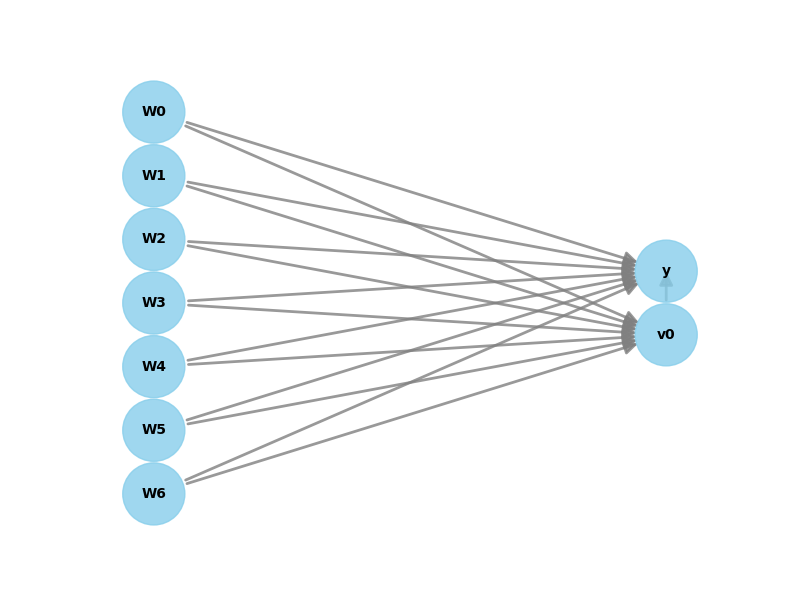

,W0,W1,W2,W3,W4,W5,W6,v0,y
0,-0.145062,-0.235286,0.784843,0.869131,-1.567724,-1.290234,0.116096,True,1.386517
1,-0.228109,-0.020264,-0.589792,0.188139,-2.649265,-1.764439,-0.167236,False,-16.159402
2,0.868298,-1.097642,-0.109792,0.487635,-1.861375,-0.527930,-0.066542,False,-0.702560
3,-0.017115,1.123918,0.346060,1.845425,0.848049,0.778865,0.596496,True,27.714465
4,-0.757347,-1.426205,-0.457063,1.528053,-2.681410,0.394312,-0.687839,False,-20.082633


In [5]:
model = CausalModel(
            data=data["df"],
            treatment=data["treatment_name"],
            outcome=data["outcome_name"],
            graph=data["gml_graph"],
            test_significance=None,
        )
model.view_model()
from IPython.display import Image, display
display(Image(filename="causal_model.png"))
data['df'].head()

## Step 3: Create Causal Model  
Remove one of the common causes to simulate unobserved confounding

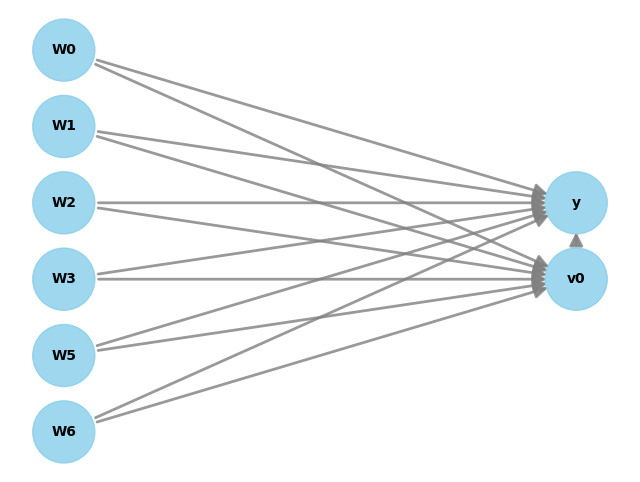

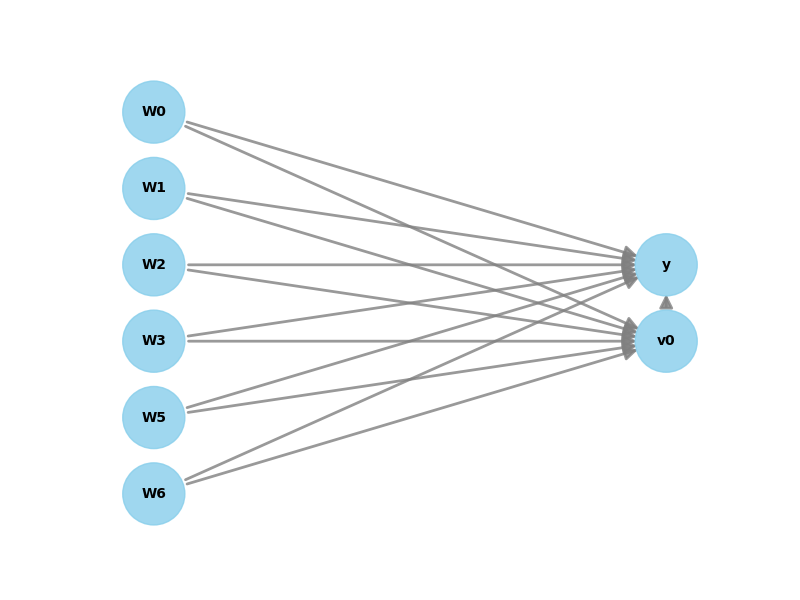

,W0,W1,W2,W3,W5,W6,v0,y
0,-0.145062,-0.235286,0.784843,0.869131,-1.290234,0.116096,True,1.386517
1,-0.228109,-0.020264,-0.589792,0.188139,-1.764439,-0.167236,False,-16.159402
2,0.868298,-1.097642,-0.109792,0.487635,-0.527930,-0.066542,False,-0.702560
3,-0.017115,1.123918,0.346060,1.845425,0.778865,0.596496,True,27.714465
4,-0.757347,-1.426205,-0.457063,1.528053,0.394312,-0.687839,False,-20.082633


In [6]:
data["df"] = data["df"].drop("W4", axis = 1)
graph_str = 'graph[directed 1node[ id "y" label "y"]node[ id "W0" label "W0"] node[ id "W1" label "W1"] node[ id "W2" label "W2"] node[ id "W3" label "W3"]  node[ id "W5" label "W5"] node[ id "W6" label "W6"]node[ id "v0" label "v0"]edge[source "v0" target "y"]edge[ source "W0" target "v0"] edge[ source "W1" target "v0"] edge[ source "W2" target "v0"] edge[ source "W3" target "v0"] edge[ source "W5" target "v0"] edge[ source "W6" target "v0"]edge[ source "W0" target "y"] edge[ source "W1" target "y"] edge[ source "W2" target "y"] edge[ source "W3" target "y"] edge[ source "W5" target "y"] edge[ source "W6" target "y"]]'
model = CausalModel(
            data=data["df"],
            treatment=data["treatment_name"],
            outcome=data["outcome_name"],
            graph=graph_str,
            test_significance=None,
        )
model.view_model()
from IPython.display import Image, display
display(Image(filename="causal_model.png"))
data['df'].head()

## Step 4: Identification

In [7]:
import dowhy
import networkx as nx

print(f"dowhy version: {dowhy.__version__}")
print(f"networkx version: {nx.__version__}")

dowhy version: 0.12
networkx version: 2.8.8


In [8]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                          
─────(E[y|W2,W3,W5,W1,W6,W0])
d[v₀]                        
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W2,W3,W5,W1,W6,W0,U) = P(y|v0,W2,W3,W5,W1,W6,W0)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



## Step 5: Estimation
Currently only Linear Regression estimator is supported for Linear Sensitivity Analysis

In [9]:
estimate = model.estimate_effect(identified_estimand,method_name="backdoor.linear_regression")
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                          
─────(E[y|W2,W3,W5,W1,W6,W0])
d[v₀]                        
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W2,W3,W5,W1,W6,W0,U) = P(y|v0,W2,W3,W5,W1,W6,W0)

## Realized estimand
b: y~v0+W2+W3+W5+W1+W6+W0
Target units: ate

## Estimate
Mean value: 10.697677486880911



/home/tc_unix/causal-inference-in-python-code/.venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]


## Step 6a: Refutation and Sensitivity Analysis - Method 1  
identified_estimand:  An instance of the identifiedEstimand class that provides the information with respect to which causal pathways are employed when the treatment effects the outcome 

estimate: An instance of CausalEstimate class.  The estimate obtained from the estimator for the original data.   

method_name: Refutation method name  

simulation_method: “linear-partial-R2” for Linear Sensitivity Analysis 

benchmark_common_causes: Name of the covariates used to bound the strengths of unobserved confounder   

percent_change_estimate: It is the percentage of reduction of treatment estimate that could alter the results (default = 1) 
if percent_change_estimate = 1, the robustness value describes the strength of association of confounders with treatment and outcome in order to reduce the estimate by 100% i.e bring it down to 0. 

confounder_increases_estimate: confounder_increases_estimate = True implies that confounder increases the absolute value of estimate and vice versa. 
Default is confounder_increases_estimate = False i.e. the considered confounders pull estimate towards zero 

effect_fraction_on_treatment: Strength of association between unobserved confounder and treatment compared to benchmark covariate 

effect_fraction_on_outcome: Strength of association between unobserved confounder and outcome compared to benchmark covariate 

null_hypothesis_effect: assumed effect under the null hypothesis (default = 0) 

plot_estimate: Generate contour plot for estimate while performing sensitivity analysis. (default = True).  
To override the setting, set plot_estimate = False.

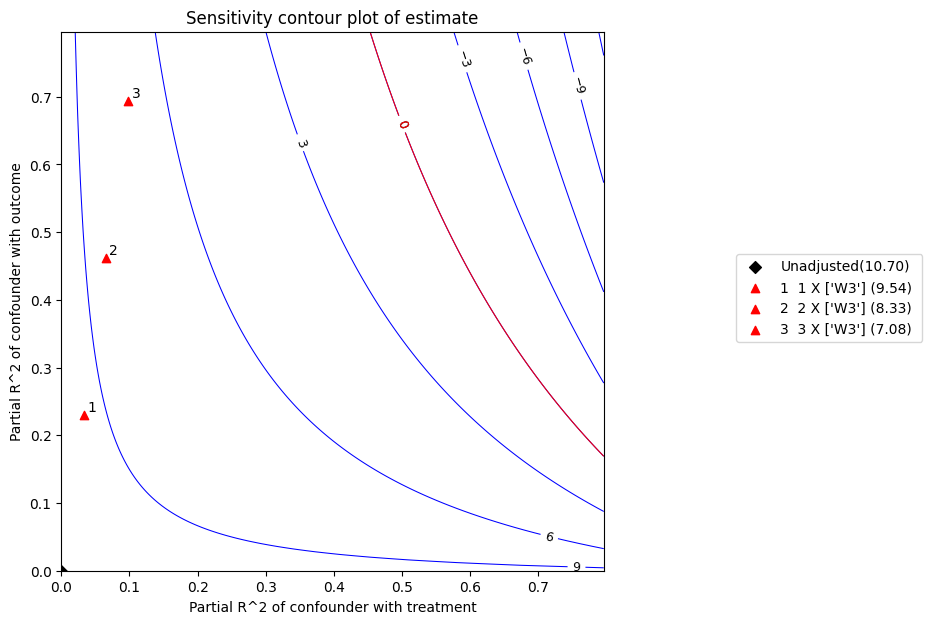

In [10]:
refute = model.refute_estimate(identified_estimand, estimate ,
                               method_name = "add_unobserved_common_cause",
                               simulation_method = "linear-partial-R2",
                               benchmark_common_causes = ["W3"],
                               effect_fraction_on_treatment = [ 1,2,3]
                              )

The x axis shows hypothetical partial R2 values of unobserved confounder(s) with the treatment.  

The y axis shows hypothetical partial R2 of unobserved confounder(s) with the outcome.  

The contour levels represent adjusted t-values or estimates for unobserved confounders with   
hypothetical partial R2 values when these would be included in full regression model.  

The red line is the critical threshold:  
confounders with such strength or stronger are sufficient to invalidate the research conclusions.

In [11]:
refute.stats

{'estimate': 10.697677486880911,
 'standard_error': 0.5938735661282941,
 'degree of freedom': 492,
 't_statistic': 18.013392238727626,
 'r2yt_w': 0.3974149837266683,
 'partial_f2': 0.6595168698094567,
 'robustness_value': 0.5467445572181009,
 'robustness_value_alpha': 0.5076289101030926}

In [12]:
refute.benchmarking_results

,r2tu_w,r2yu_tw,bias_adjusted_estimate,bias_adjusted_se,bias_adjusted_t,bias_adjusted_lower_CI,bias_adjusted_upper_CI
0,0.032677,0.230238,9.535964,0.530308,17.981928,8.494016,10.577912
1,0.065354,0.461490,8.331381,0.451241,18.463243,7.444783,9.217979
2,0.098031,0.693855,7.080284,0.346341,20.443123,6.399795,7.760773


## Parameter List for plot function
plot_type: “estimate” or “t-value” 

critical_value: special reference value of the estimate or t-value that will be highlighted in the plot 

x_limit: plot’s maximum x_axis value (default = 0.8) 

y_limit: plot’s minimum y_axis value (default = 0.8) 

num_points_per_contour: number of points to calculate and plot each contour line (default = 200) 

plot_size: tuple denoting the size of the plot (default = (7,7)) 

contours_color: color of contour line (default = blue)  
String or array.  If array, lines will be plotted with the specific color in ascending order.  

critical_contour_color: color of threshold line (default = red) 

label_fontsize: fontsize for labelling contours (default = 9)  

contour_linewidths: linewidths for contours (default = 0.75)   

contour_linestyles: linestyles for contours (default = “solid”)  
See : https://matplotlib.org/3.5.0/gallery/lines_bars_and_markers/linestyles.html 

contours_label_color: color of contour line label (default = black) 

critical_label_color: color of threshold line label (default = red) 

unadjusted_estimate_marker: marker type for unadjusted estimate in the plot (default = ‘D’)   
See: https://matplotlib.org/stable/api/markers_api.html   

unadjusted_estimate_color: marker color for unadjusted estimate in the plot (default = “black”)  

adjusted_estimate_marker: marker type for bias adjusted estimates in the plot (default = ‘^’)  

adjusted_estimate_color: marker color for bias adjusted estimates in the plot (default = “red”)  

legend_position:tuple denoting the position of the legend (default = (1.6, 0.6))  

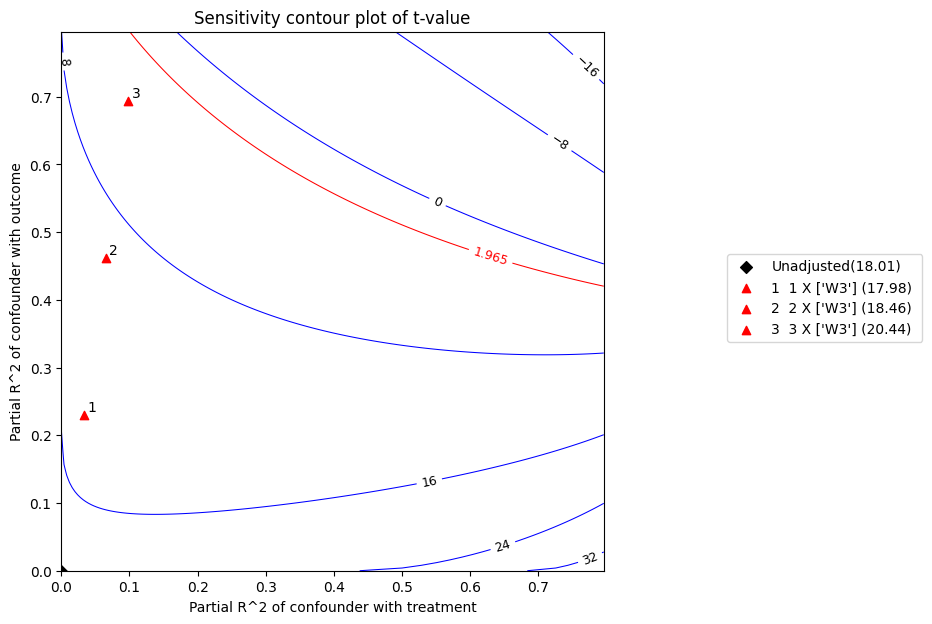

In [13]:
refute.plot(plot_type = 't-value')

The t statistic is the coefficient divided by its standard error.  
The higher the t-value, the greater the evidence to reject the null hypothesis.  

According to the above plot, at 5% significance level,  
the null hypothesis of zero effect would be rejected given the above confounders.

In [14]:
print(refute)

Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['v0'] :
Coefficient Estimate : 10.697677486880911
Degree of Freedom : 492
Standard Error : 0.5938735661282941
t-value : 18.013392238727626
F^2 value : 0.6595168698094567

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.3974149837266683
Robustness Value : 0.5467445572181009

Interpretation of results :
Any confounder explaining less than 54.67% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 50.76% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of the outcome, they would need to explain at least 39.74% of the res

## Step 6b: Refutation and Sensitivity Analysis - Method 2  
simulated_method_name: “e-value” for E-value

num_points_per_contour: number of points to calculate and plot for each contour (Default = 200)  

plot_size: size of the plot (Default = (6.4,4.8))  

contour_colors: colors for point estimate and confidence limit contour (Default = [“blue”, “red])  

xy_limit: plot’s maximum x and y value. Default is 2 x E-value. (Default = None)  

/home/tc_unix/causal-inference-in-python-code/.venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/tc_unix/causal-inference-in-python-code/.venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/tc_unix/causal-inference-in-python-code/.venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating k

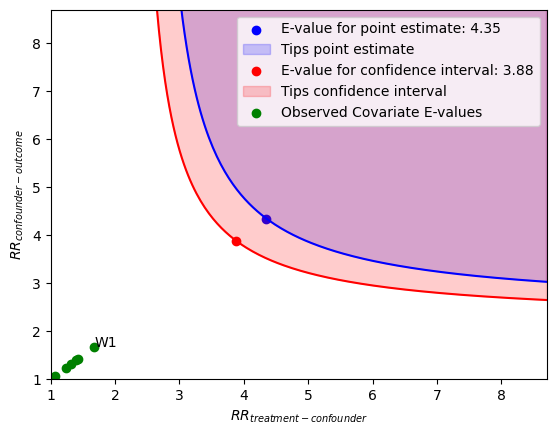

In [15]:
refute = model.refute_estimate(identified_estimand, estimate ,
                               method_name = "add_unobserved_common_cause",
                               simulation_method = "e-value",
                              )

- The x axis shows hypothetical values of the risk ratio of an unmeasured confounder  
at different levels of the treatment.  
The y axis shows hypothetical values of the risk ratio of the outcome at different levels of the confounder.

- Points lying on or above the blue contour represent   
combinations of these risk ratios that would tip (i.e. explain away) the point estimate.

- Points lying on or above the red contour represent   
combinations of these risk ratios that would tip (i.e. explain away) the confidence interval.

- The green points are Observed Covariate E-values.   
These measure how much the limiting bound of the confidence interval changes  
on the E-value scale after a specific covariate is dropped and the estimator is re-fit.   
The covariate that corresponds to the largest Observed Covariate E-value is labeled.  

In [16]:
refute.stats

{'converted_estimate': 2.4574470657354213,
 'converted_lower_ci': 2.228856727004313,
 'converted_upper_ci': 2.709481505797993,
 'evalue_estimate': 4.3499583642898605,
 'evalue_lower_ci': 3.883832733630411,
 'evalue_upper_ci': None}

In [17]:
refute.benchmarking_results

,converted_est,converted_lower_ci,converted_upper_ci,observed_covariate_e_value
dropped_covariate,,,,
W1,2.992523,2.666604,3.358276,1.681140
W6,2.687656,2.446341,2.952774,1.424835
W3,2.692807,2.422402,2.993396,1.394043
W0,2.599868,2.368550,2.853776,1.320751
W5,2.553701,2.315245,2.816716,1.239411
W2,2.473648,2.217699,2.759138,1.076142


In [18]:
print(refute)

Sensitivity Analysis to Unobserved Confounding using the E-value

Unadjusted Estimates of Treatment: v0
Estimate (converted to risk ratio scale): 2.4574470657354213
Lower 95% CI (converted to risk ratio scale): 2.228856727004313
Upper 95% CI (converted to risk ratio scale): 2.709481505797993

Sensitivity Statistics: 
E-value for point estimate: 4.3499583642898605
E-value for lower 95% CI: 3.883832733630411
E-value for upper 95% CI: None
Largest Observed Covariate E-value: 1.6811401167656814 (W1)

Interpretation of results:
Unmeasured confounder(s) would have to be associated with a 4.35-fold increase in the risk of y, and must be 4.35 times more prevalent in v0, to explain away the observed point estimate.
Unmeasured confounder(s) would have to be associated with a 3.88-fold increase in the risk of y, and must be 3.88 times more prevalent in v0, to explain away the observed confidence interval.


We now run the sensitivity analysis for the same dataset but without dropping any variable.  

We get a robustness value goes from 0.55 to 0.95 which means that treatment effect   
can handle strong confounders explaining almost all residual variation of the treatment and the outcome.

In [19]:
np.random.seed(100)
data = dowhy.datasets.linear_dataset( beta = 10,
                                      num_common_causes = 7,
                                      num_samples = 500,
                                      num_treatments = 1,
                                     stddev_treatment_noise=10,
                                     stddev_outcome_noise = 1
                                    )

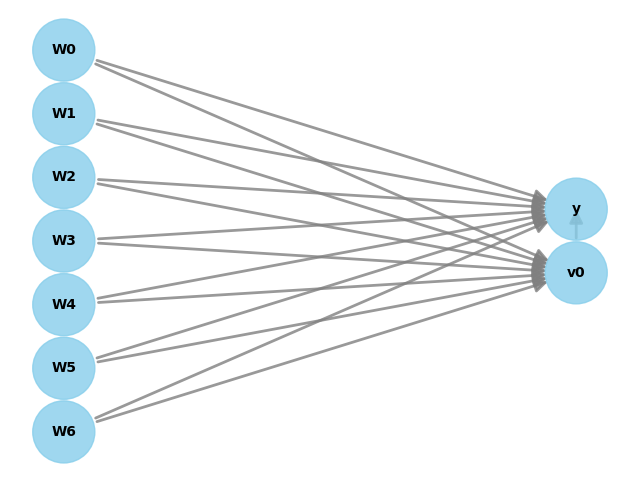

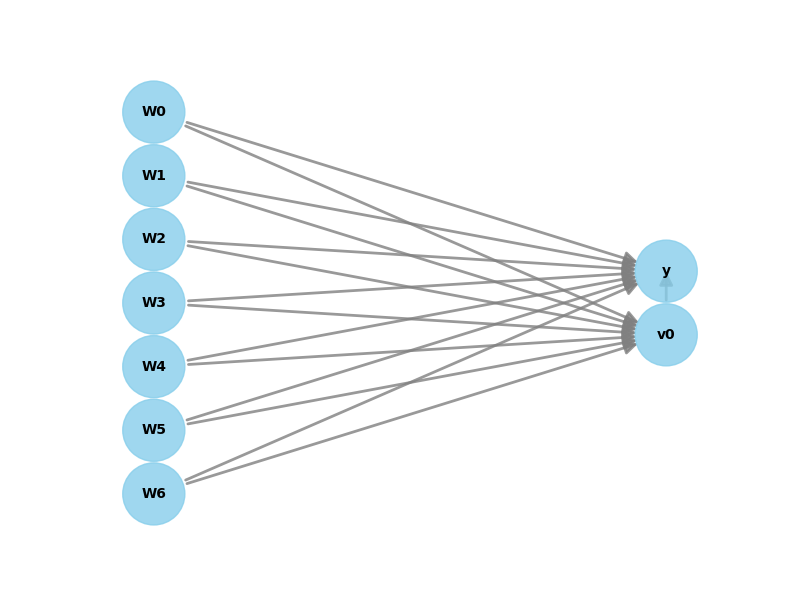

,W0,W1,W2,W3,W4,W5,W6,v0,y
0,-0.145062,-0.235286,0.784843,0.869131,-1.567724,-1.290234,0.116096,True,6.311809
1,-0.228109,-0.020264,-0.589792,0.188139,-2.649265,-1.764439,-0.167236,False,-12.274406
2,0.868298,-1.097642,-0.109792,0.487635,-1.861375,-0.527930,-0.066542,False,-6.487561
3,-0.017115,1.123918,0.346060,1.845425,0.848049,0.778865,0.596496,True,24.653183
4,-0.757347,-1.426205,-0.457063,1.528053,-2.681410,0.394312,-0.687839,False,-13.770396


In [20]:
model = CausalModel(
            data=data["df"],
            treatment=data["treatment_name"],
            outcome=data["outcome_name"],
            graph=data["gml_graph"],
            test_significance=None,
        )
model.view_model()
from IPython.display import Image, display
display(Image(filename="causal_model.png"))
data['df'].head()

In [21]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                             
─────(E[y|W1,W2,W3,W5,W4,W6,W0])
d[v₀]                           
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W2,W3,W5,W4,W6,W0,U) = P(y|v0,W1,W2,W3,W5,W4,W6,W0)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



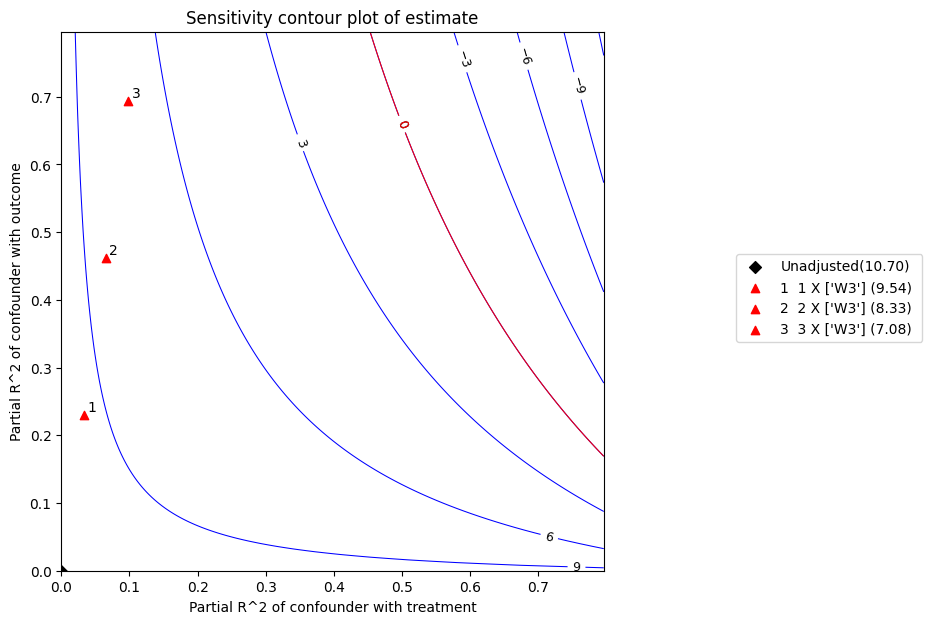

In [22]:
refute = model.refute_estimate(identified_estimand, estimate ,
                               method_name = "add_unobserved_common_cause",
                               simulation_method = "linear-partial-R2",
                               benchmark_common_causes = ["W3"],
                               effect_fraction_on_treatment = [ 1,2,3])

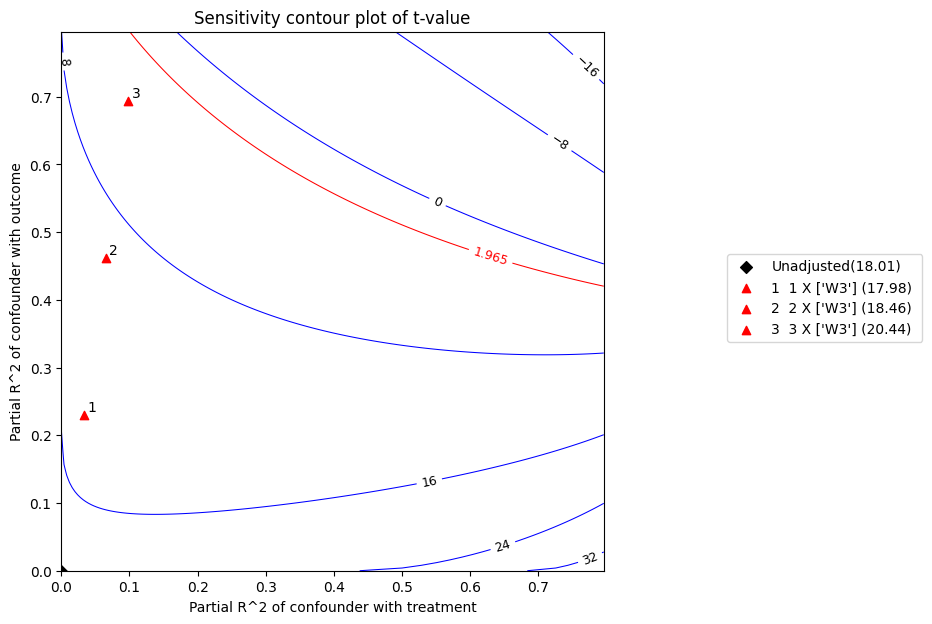

In [23]:
refute.plot(plot_type = 't-value')

In [24]:
print(refute)

Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['v0'] :
Coefficient Estimate : 10.697677486880911
Degree of Freedom : 492
Standard Error : 0.5938735661282941
t-value : 18.013392238727626
F^2 value : 0.6595168698094567

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.3974149837266683
Robustness Value : 0.5467445572181009

Interpretation of results :
Any confounder explaining less than 54.67% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 50.76% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of the outcome, they would need to explain at least 39.74% of the res

In [25]:
refute.stats

{'estimate': 10.697677486880911,
 'standard_error': 0.5938735661282941,
 'degree of freedom': 492,
 't_statistic': 18.013392238727626,
 'r2yt_w': 0.3974149837266683,
 'partial_f2': 0.6595168698094567,
 'robustness_value': 0.5467445572181009,
 'robustness_value_alpha': 0.5076289101030926}

In [26]:
refute.benchmarking_results

,r2tu_w,r2yu_tw,bias_adjusted_estimate,bias_adjusted_se,bias_adjusted_t,bias_adjusted_lower_CI,bias_adjusted_upper_CI
0,0.032677,0.230238,9.535964,0.530308,17.981928,8.494016,10.577912
1,0.065354,0.461490,8.331381,0.451241,18.463243,7.444783,9.217979
2,0.098031,0.693855,7.080284,0.346341,20.443123,6.399795,7.760773


## The End